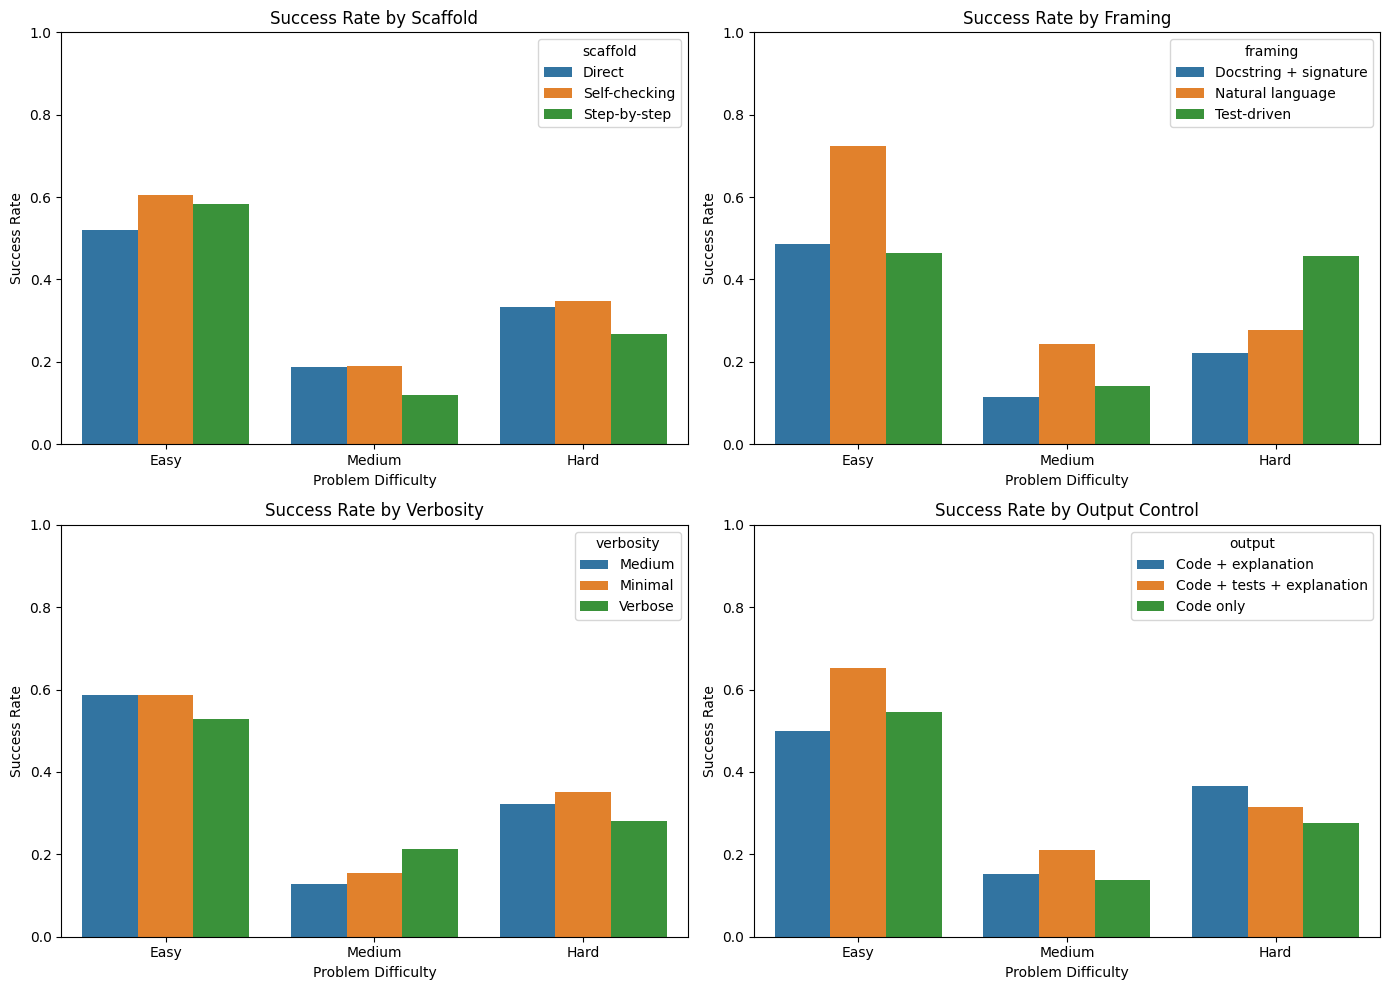

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import json
import pandas as pd

model = "qwen"
files = [f"../results/results_easy_{model}.json", 
         f"../results/results_medium_{model}.json", 
         f"../results/results_hard_{model}.json"]

all_data = []
for f in files:
    with open(f) as infile:
        all_data.extend(json.load(infile))

df = pd.DataFrame(all_data)
df = df[["problem", "framing", "scaffold", "verbosity", "output", "passed", "error"]]

# Clean problem names
df["problem"] = df["problem"].str.replace(" – .*", "", regex=True)
order = ["Easy", "Medium", "Hard"]

# Prepare subplots (2x2 grid for 4 plots)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 1. Scaffold performance
scaffold_perf = df.groupby(["problem", "scaffold"])["passed"].mean().reset_index()
sns.barplot(data=scaffold_perf, x="problem", y="passed", hue="scaffold", order=order, ax=axes[0])
axes[0].set_title("Success Rate by Scaffold")

# 2. Framing performance
framing_perf = df.groupby(["problem", "framing"])["passed"].mean().reset_index()
sns.barplot(data=framing_perf, x="problem", y="passed", hue="framing", order=order, ax=axes[1])
axes[1].set_title("Success Rate by Framing")

# 3. Verbosity
verbosity_perf = df.groupby(["problem", "verbosity"])["passed"].mean().reset_index()
sns.barplot(data=verbosity_perf, x="problem", y="passed", hue="verbosity", order=order, ax=axes[2])
axes[2].set_title("Success Rate by Verbosity")

# 4. Output control
output_perf = df.groupby(["problem", "output"])["passed"].mean().reset_index()
sns.barplot(data=output_perf, x="problem", y="passed", hue="output", order=order, ax=axes[3])
axes[3].set_title("Success Rate by Output Control")

# Clean up axes
for ax in axes:
    ax.set_ylim(0, 1)
    ax.set_xlabel("Problem Difficulty")
    ax.set_ylabel("Success Rate")

plt.tight_layout()
plt.show()


### Organizing Data

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import json

with open("../results/results_kattis.json") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Expand prompt_variant dictionary
df = pd.concat([df.drop(["prompt_variant"], axis=1), df["prompt_variant"].apply(pd.Series)], axis=1)

# Compute accuracy as fraction of test cases passed
df["accuracy"] = df["test_summary"].apply(lambda x: x["passed"] / x["total"] if x and x["total"] > 0 else 0)

# Add binary success flag
df["success"] = df["passed"].astype(bool)

# Clean up
df.drop(columns=["prompt", "raw_code", "error", "test_summary"], inplace=True)
df.head()

overall_success = df["success"].mean()
print(f"Overall success rate: {overall_success:.2%}")

group_stats = df.groupby(["reasoning", "decomposition", "output_control"]).agg(
    success_rate=("success", "mean"),
    avg_accuracy=("accuracy", "mean"),
    n=("problem", "count")
).reset_index()



Overall success rate: 2.45%


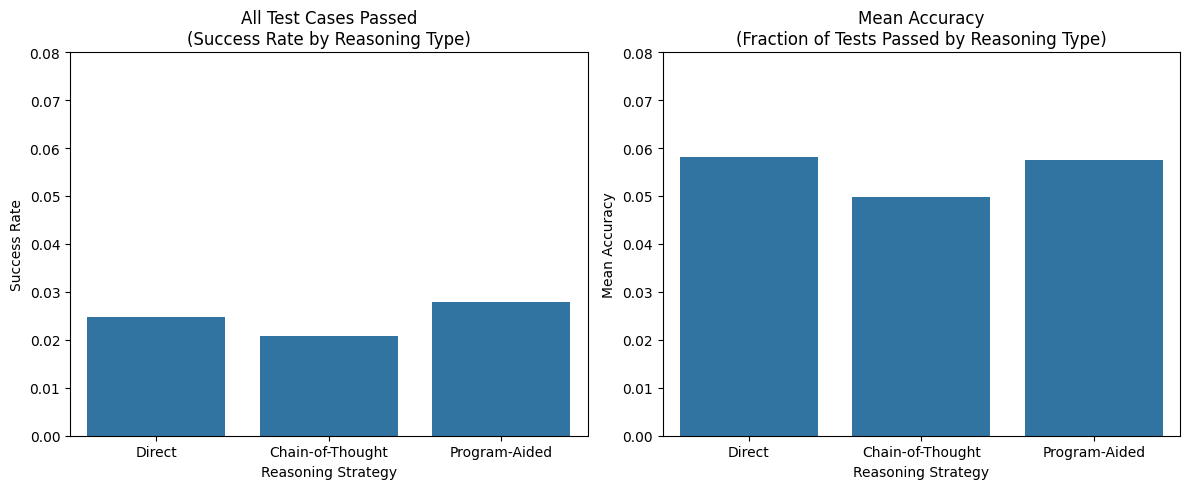

In [ ]:
# Create a side-by-side layout
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# --- Success Rate (All Tests Passed) ---
sns.barplot(
    x="reasoning", 
    y="success", 
    data=df, 
    estimator=lambda x: sum(x)/len(x), 
    errorbar=None, 
    ax=axes[0]
)
axes[0].set_title("All Test Cases Passed\n(Success Rate by Reasoning Type)")
axes[0].set_ylabel("Success Rate")
axes[0].set_xlabel("Reasoning Strategy")
axes[0].set_ylim(0, 0.08)

# --- Mean Accuracy ---
sns.barplot(
    x="reasoning", 
    y="accuracy", 
    data=df, 
    estimator=lambda x: sum(x)/len(x), 
    errorbar=None, 
    ax=axes[1]
)
axes[1].set_title("Mean Accuracy\n(Fraction of Tests Passed by Reasoning Type)")
axes[1].set_ylabel("Mean Accuracy")
axes[1].set_xlabel("Reasoning Strategy")
axes[1].set_ylim(0, 0.08)

# Adjust layout for cleaner look
plt.tight_layout()
plt.show()

## Make plots like this comparing each category


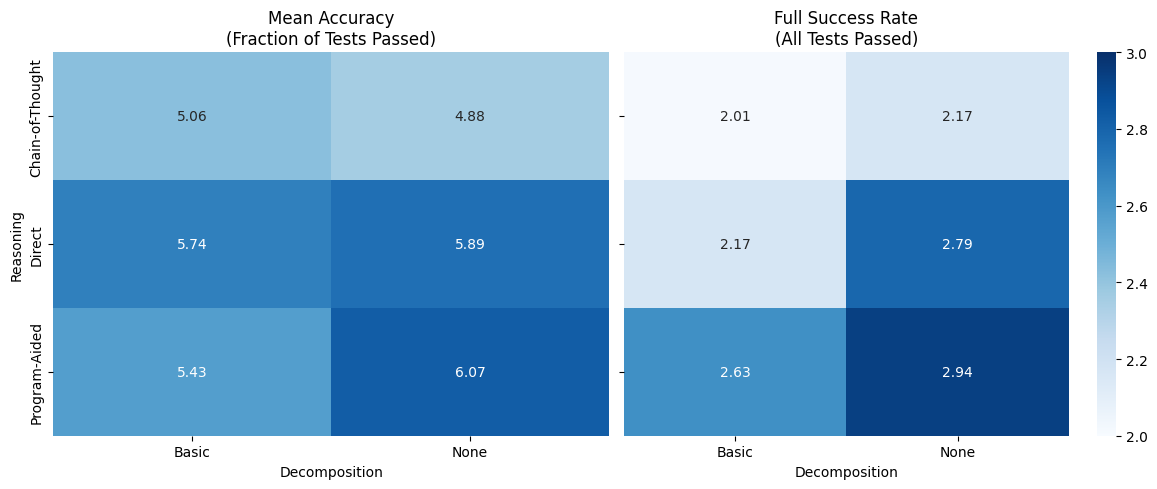

In [68]:
# --- Compute both pivot tables ---
pivot_accuracy = df.pivot_table(
    values="accuracy", 
    index="reasoning", 
    columns="decomposition", 
    aggfunc="mean"
).mul(100).round(3)

pivot_success = df.pivot_table(
    values="success", 
    index="reasoning", 
    columns="decomposition", 
    aggfunc="mean"
).mul(100).round(3)

# --- Create side-by-side heatmaps ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Mean Accuracy
sns.heatmap(
    pivot_accuracy, 
    annot=True, 
    cmap="Blues", 
    fmt=".2f", 
    ax=axes[0],
    cbar=False,
    vmin=4,
    vmax=6.5
)
axes[0].set_title("Mean Accuracy\n(Fraction of Tests Passed)")
axes[0].set_xlabel("Decomposition")
axes[0].set_ylabel("Reasoning")

# Full Success Rate
sns.heatmap(
    pivot_success, 
    annot=True, 
    cmap="Blues", 
    fmt=".2f", 
    ax=axes[1],
    cbar=True,
    vmin=2,
    vmax=3
)
axes[1].set_title("Full Success Rate\n(All Tests Passed)")
axes[1].set_xlabel("Decomposition")
axes[1].set_ylabel("")

# --- Adjust layout ---
plt.tight_layout()
plt.show()


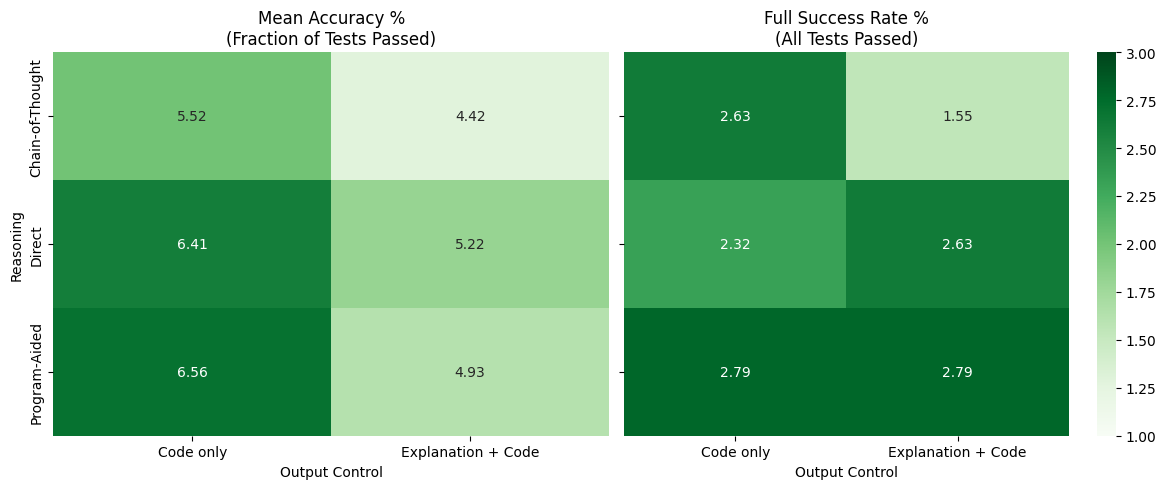

In [62]:
# --- Compute both pivot tables ---
pivot_accuracy = df.pivot_table(
    values="accuracy",
    index="reasoning",
    columns="output_control",
    aggfunc="mean"
).mul(100).round(3)

pivot_success = df.pivot_table(
    values="success",
    index="reasoning",
    columns="output_control",
    aggfunc="mean"
).mul(100).round(3)

# --- Create side-by-side heatmaps ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Mean Accuracy Heatmap
sns.heatmap(
    pivot_accuracy,
    annot=True,
    cmap="Greens",
    fmt=".2f",
    ax=axes[0],
    cbar=False,
    vmin=4,
    vmax=7
)
axes[0].set_title("Mean Accuracy %\n(Fraction of Tests Passed)")
axes[0].set_xlabel("Output Control")
axes[0].set_ylabel("Reasoning")

# Full Success Rate Heatmap
sns.heatmap(
    pivot_success,
    annot=True,
    cmap="Greens",
    fmt=".2f",
    ax=axes[1],
    cbar=True,
    vmin=1,
    vmax=3
)
axes[1].set_title("Full Success Rate %\n(All Tests Passed)")
axes[1].set_xlabel("Output Control")
axes[1].set_ylabel("")

# --- Adjust layout ---
plt.tight_layout()
plt.show()


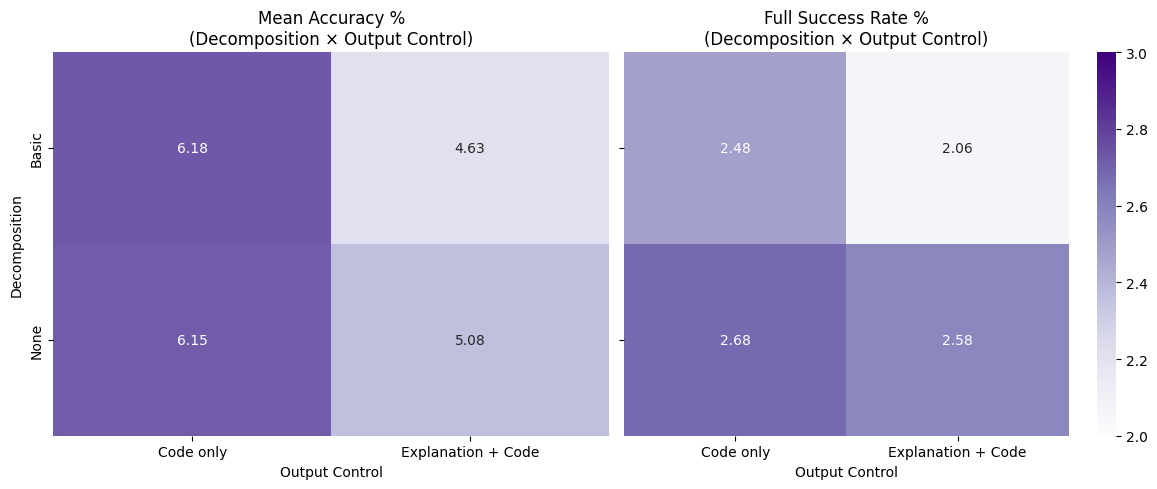

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Compute both pivot tables ---
pivot_accuracy = df.pivot_table(
    values="accuracy",
    index="decomposition",
    columns="output_control",
    aggfunc="mean"
).mul(100).round(3)

pivot_success = df.pivot_table(
    values="success",
    index="decomposition",
    columns="output_control",
    aggfunc="mean"
).mul(100).round(3)

# --- Create side-by-side heatmaps ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Mean Accuracy
sns.heatmap(
    pivot_accuracy, annot=True, cmap="Purples", fmt=".2f",
    ax=axes[0], cbar=False, vmin=4, vmax=7
)
axes[0].set_title("Mean Accuracy %\n(Decomposition × Output Control)")
axes[0].set_xlabel("Output Control")
axes[0].set_ylabel("Decomposition")

# Full Success Rate
sns.heatmap(
    pivot_success, annot=True, cmap="Purples", fmt=".2f",
    ax=axes[1], cbar=True, vmin=2, vmax=3
)
axes[1].set_title("Full Success Rate %\n(Decomposition × Output Control)")
axes[1].set_xlabel("Output Control")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


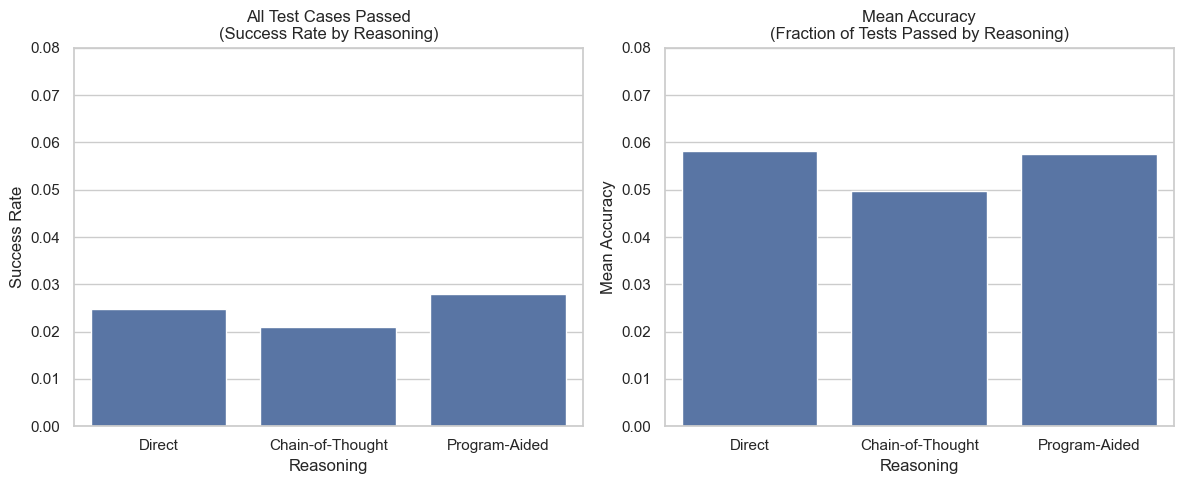

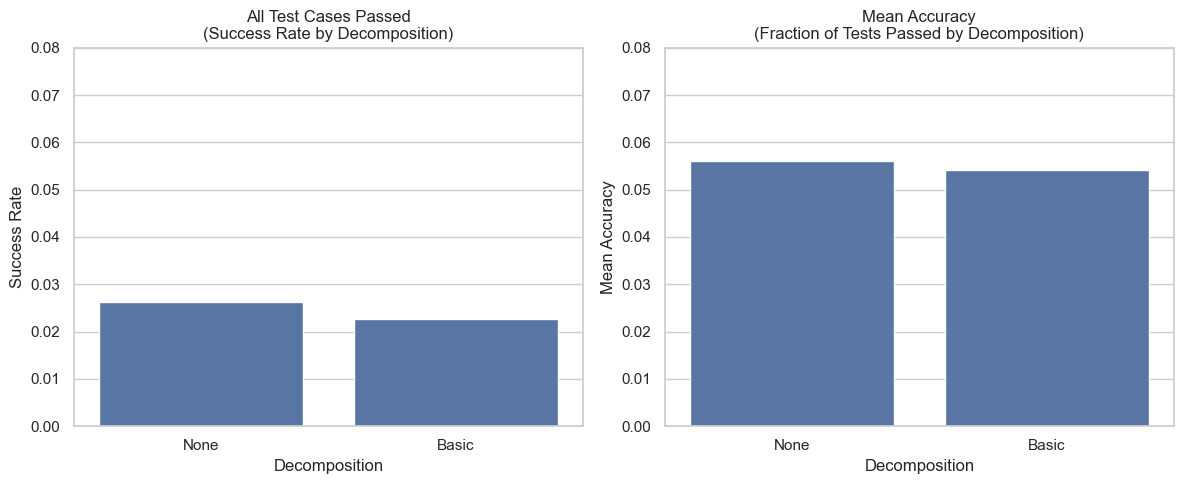

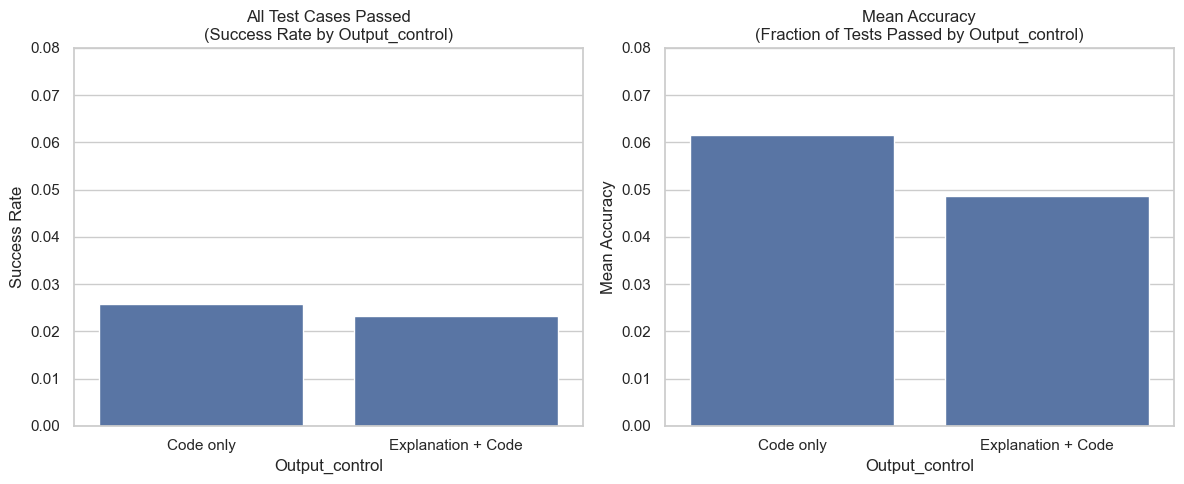

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure seaborn style for consistency
sns.set_theme(style="whitegrid")

# Helper function for side-by-side plots by category
def plot_category(df, category, ylim=(0, 0.08)):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

    # --- Success Rate (All Tests Passed) ---
    sns.barplot(
        x=category,
        y="success",
        data=df,
        estimator=lambda x: sum(x)/len(x),
        errorbar=None,
        ax=axes[0]
    )
    axes[0].set_title(f"All Test Cases Passed\n(Success Rate by {category.capitalize()})")
    axes[0].set_ylabel("Success Rate")
    axes[0].set_xlabel(category.capitalize())
    axes[0].set_ylim(*ylim)

    # --- Mean Accuracy ---
    sns.barplot(
        x=category,
        y="accuracy",
        data=df,
        estimator=lambda x: sum(x)/len(x),
        errorbar=None,
        ax=axes[1]
    )
    axes[1].set_title(f"Mean Accuracy\n(Fraction of Tests Passed by {category.capitalize()})")
    axes[1].set_ylabel("Mean Accuracy")
    axes[1].set_xlabel(category.capitalize())
    axes[1].set_ylim(*ylim)

    plt.tight_layout()
    plt.show()


# Generate plots for each prompt dimension
for cat in ["reasoning", "decomposition", "output_control"]:
    plot_category(df, category=cat)
